<a href="https://colab.research.google.com/github/xinliwvu/MTF/blob/main/mtf_vs_lear_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MTF-ViT vs LEAR: Multi-Domain Continual Learning

LEAR (NeurIPS 2025) is designed for **MDCL** -- each task is an entire domain/dataset,
not a class-split within one dataset. This is a scaled-down version of Table 1 (CDM sequence)
using 4 auto-downloadable domains with 10 classes each:

| Task | Domain | Classes | Description |
|---|---|---|---|
| 1 | CIFAR-10 | 10 | Natural images |
| 2 | SVHN | 10 | Street numbers |
| 3 | MNIST | 10 | Handwritten digits (grayscale to 3ch) |
| 4 | FashionMNIST | 10 | Fashion items (grayscale to 3ch) |

Both methods evaluated per-domain after all tasks are learned.


In [ ]:
# ============================================================
# Cell 1: Setup + Multi-Domain Data
# ============================================================
!pip install timm -q

import copy, time
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms.functional import InterpolationMode
import timm
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

# 3-channel 224x224 transforms
tf_color = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)])
tf_color_test = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)])

# Grayscale -> 3ch transforms (for MNIST, FashionMNIST)
tf_gray = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)])
tf_gray_test = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)])

domains = []

# Domain 0: CIFAR-10
tr = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=tf_color)
te = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=tf_color_test)
domains.append({'name': 'CIFAR-10', 'n_classes': 10,
                'train': DataLoader(tr, batch_size=32, shuffle=True, num_workers=2),
                'test':  DataLoader(te, batch_size=64, shuffle=False, num_workers=2)})

# Domain 1: SVHN
tr = torchvision.datasets.SVHN('./data', split='train', download=True, transform=tf_color)
te = torchvision.datasets.SVHN('./data', split='test',  download=True, transform=tf_color_test)
domains.append({'name': 'SVHN', 'n_classes': 10,
                'train': DataLoader(tr, batch_size=32, shuffle=True, num_workers=2),
                'test':  DataLoader(te, batch_size=64, shuffle=False, num_workers=2)})

# Domain 2: MNIST (grayscale -> 3ch)
tr = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=tf_gray)
te = torchvision.datasets.MNIST('./data', train=False, download=True, transform=tf_gray_test)
domains.append({'name': 'MNIST', 'n_classes': 10,
                'train': DataLoader(tr, batch_size=32, shuffle=True, num_workers=2),
                'test':  DataLoader(te, batch_size=64, shuffle=False, num_workers=2)})

# Domain 3: FashionMNIST (grayscale -> 3ch)
tr = torchvision.datasets.FashionMNIST('./data', train=True,  download=True, transform=tf_gray)
te = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=tf_gray_test)
domains.append({'name': 'FashionMNIST', 'n_classes': 10,
                'train': DataLoader(tr, batch_size=32, shuffle=True, num_workers=2),
                'test':  DataLoader(te, batch_size=64, shuffle=False, num_workers=2)})

N_DOMAINS = len(domains)
EPOCHS = 3  # per domain (paper uses 10; reduced for Colab)
print(f'{N_DOMAINS} domains: {[d["name"] for d in domains]}')


Device: cuda


100%|██████████| 170M/170M [00:03<00:00, 42.9MB/s]
100%|██████████| 182M/182M [00:01<00:00, 100MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 50.3MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.4MB/s]

4 domains: ['CIFAR-10', 'SVHN', 'MNIST', 'FashionMNIST']


In [ ]:
# ============================================================
# Cell 2: Shared Utilities
# ============================================================

def pairwise_distances(x):
    norm = torch.sum(x**2, -1).reshape((-1, 1))
    return -2*torch.mm(x, x.t()) + norm + norm.t()

def GaussianKernelMatrix(x, sigma=1):
    return torch.exp(-pairwise_distances(x) / sigma)

def hsic(x, y, s_x=1, s_y=1):
    m, _ = x.shape
    K = GaussianKernelMatrix(x, s_x)
    L = GaussianKernelMatrix(y, s_y)
    H = (torch.eye(m) - 1.0/m * torch.ones((m, m))).to(x.device)
    return torch.trace(torch.mm(L, torch.mm(H, torch.mm(K, H)))) / ((m-1)**2)

def kl_loss(student, teacher):
    s = F.normalize(student, p=2, dim=1)
    t = F.normalize(teacher.detach(), p=2, dim=1)
    return F.kl_div(torch.log((s+1)/2 + 1e-10), (t+1)/2, reduction='batchmean')

def eval_domain(predict_fn, test_loader):
    """Evaluate per-domain accuracy. predict_fn(x) -> logits."""
    correct, total = 0, 0
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.no_grad():
            logits = predict_fn(x)
            pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += len(y)
    return correct / total if total > 0 else 0.0

print('Utilities defined.')


Utilities defined.


## LEAR (NeurIPS 2025) -- Multi-Domain Continual Learning

In [ ]:
# ============================================================
# Cell 3: LEAR for MDCL (faithful to paper)
# ============================================================
# Architecture: dual ViT (global + local), last 3 blocks unfrozen
# Per-domain: lightweight expert (fc 768->500 + classifier 1268->n_classes)
# Training: CE + HSIC (task 0), CE + KL + L2 + HSIC (tasks 1+)
# Expert routing: Mahalanobis distance on FC-projected features
# Key: fc/classifier in PLAIN LISTS (not nn.ModuleList) => not in optimizer
#      Only ViT blocks are trained. FC/classifier act as fixed random projections.

class LEARModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model_dim = 768
        self.fc_dim = 500
        self.local_vit  = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        self.global_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        for vit in [self.local_vit, self.global_vit]:
            for p in vit.parameters(): p.requires_grad = False
            for block in vit.blocks[-3:]:
                for p in block.parameters(): p.requires_grad = True
        self.forever_frozen = copy.deepcopy(nn.Sequential(*list(self.local_vit.blocks[-3:])))
        for p in self.forever_frozen.parameters(): p.requires_grad = False
        # Plain lists (NOT nn.ModuleList) — matches original exactly
        self.fcArr = []
        self.classifierArr = []
        self.distributions = []  # (mu, sigma_inv) per expert
        self.frozen_local = None
        self.frozen_global = None
        self.c_expert = -1

    def _add_expert(self, n_classes, clone_from=None):
        fc = nn.Linear(self.model_dim, self.fc_dim).to(DEVICE)
        if clone_from is not None and clone_from < len(self.fcArr):
            fc.load_state_dict(self.fcArr[clone_from].state_dict())
        self.fcArr.append(fc)
        cls = nn.Linear(self.model_dim + self.fc_dim, n_classes).to(DEVICE)
        self.classifierArr.append(cls)
        self.c_expert = len(self.classifierArr) - 1

    def forward_fusion(self, x, return_frozen=False):
        lf = self.local_vit.patch_embed(x)
        lf = torch.cat((self.local_vit.cls_token.expand(lf.shape[0],-1,-1), lf), dim=1)
        lf = lf + self.local_vit.pos_embed
        for block in self.local_vit.blocks[:-3]: lf = block(lf)

        gf = self.global_vit.patch_embed(x)
        gf = torch.cat((self.global_vit.cls_token.expand(gf.shape[0],-1,-1), gf), dim=1)
        gf = gf + self.global_vit.pos_embed
        for block in self.global_vit.blocks[:-3]: gf = block(gf)

        fgf, flf = None, None
        if return_frozen and self.frozen_local is not None:
            fgf = self.global_vit.norm(self.frozen_global(gf))[:, 0, :]
            flf = self.local_vit.norm(self.frozen_local(lf))[:, 0, :]

        for block in self.local_vit.blocks[-3:]:  lf = block(lf)
        for block in self.global_vit.blocks[-3:]: gf = block(gf)
        lf = self.local_vit.norm(lf)[:, 0, :]
        gf = self.global_vit.norm(gf)[:, 0, :]
        if return_frozen: return gf, lf, fgf, flf
        return gf, lf

    def predict(self, x, expert_idx):
        with torch.no_grad():
            gf, lf = self.forward_fusion(x)
            fc_out = self.fcArr[expert_idx](lf)
            return self.classifierArr[expert_idx](torch.cat((gf, fc_out), dim=1))

    def frozen_features(self, x):
        lf = self.local_vit.patch_embed(x)
        lf = torch.cat((self.local_vit.cls_token.expand(lf.shape[0],-1,-1), lf), dim=1)
        lf = lf + self.local_vit.pos_embed
        for block in self.local_vit.blocks[:-3]: lf = block(lf)
        lf = self.forever_frozen(lf)
        return self.local_vit.norm(lf)[:, 0, :]

    def route(self, x):
        """Select best expert via Mahalanobis distance."""
        with torch.no_grad():
            ff = self.frozen_features(x)
        if len(self.distributions) <= 1: return 0
        dists = []
        for k, (mu, sinv) in enumerate(self.distributions):
            delta = self.fcArr[k](ff) - mu
            maha = torch.sqrt((delta @ sinv @ delta.T).diagonal().clamp(min=1e-12))
            dists.append(maha.mean().item())
        return int(np.argmin(dists))

    def get_vit_params(self):
        params = []
        for vit in [self.local_vit, self.global_vit]:
            for block in vit.blocks[-3:]:
                params.extend([p for p in block.parameters() if p.requires_grad])
        return params


def run_lear(domains, epochs=3):
    print('\n' + '='*60)
    print('LEAR (NeurIPS 2025) -- MDCL')
    print('='*60)
    model = LEARModel().to(DEVICE)
    l2_fn = nn.MSELoss()
    results = {}

    for t in range(N_DOMAINS):
        dom = domains[t]
        print(f'\nTask {t+1}/{N_DOMAINS}: {dom["name"]} ({dom["n_classes"]} classes)')

        # Begin task: select closest expert + create new
        if t > 0:
            dists_accum = [0.0] * len(model.distributions)
            n = 0
            for x, y in dom['train']:
                x = x.to(DEVICE)
                with torch.no_grad(): ff = model.frozen_features(x)
                for k, (mu, sinv) in enumerate(model.distributions):
                    delta = model.fcArr[k](ff) - mu
                    maha = torch.sqrt((delta @ sinv @ delta.T).diagonal().clamp(min=1e-12))
                    dists_accum[k] += maha.mean().item()
                n += 1
                if n >= 50: break
            closest = int(np.argmin(dists_accum))
            model._add_expert(dom['n_classes'], clone_from=closest)
            print(f'  Expert {model.c_expert} created (cloned from {closest})')
        else:
            model._add_expert(dom['n_classes'])
            print(f'  Expert 0 created')

        opt = torch.optim.SGD(model.get_vit_params(), lr=0.03, momentum=0.9)

        # Train
        for ep in range(epochs):
            model.train()
            ep_loss = 0; n = 0
            for x, y in dom['train']:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                if t > 0:
                    gf, lf, fgf, flf = model.forward_fusion(x, return_frozen=True)
                    fc_out = model.fcArr[model.c_expert](lf)
                    logits = model.classifierArr[model.c_expert](torch.cat((gf, fc_out), dim=1))
                    loss = F.cross_entropy(logits, y) + kl_loss(lf, flf) + l2_fn(gf, fgf) - hsic(gf, lf)
                else:
                    gf, lf = model.forward_fusion(x)
                    fc_out = model.fcArr[model.c_expert](lf)
                    logits = model.classifierArr[model.c_expert](torch.cat((gf, fc_out), dim=1))
                    loss = F.cross_entropy(logits, y) - hsic(gf, lf)
                loss.backward()
                opt.step()
                ep_loss += F.cross_entropy(logits, y).item() * len(x); n += len(x)
            print(f'    Epoch {ep+1}/{epochs}, CE={ep_loss/n:.3f}')

        # End task: distribution + freeze blocks
        fc_feats = []
        with torch.no_grad():
            nb = 0
            for x, y in dom['train']:
                x = x.to(DEVICE)
                ff = model.frozen_features(x)
                fc_feats.append(model.fcArr[t](ff))
                nb += 1
                if nb >= 100: break
        fc_feats = torch.nan_to_num(torch.cat(fc_feats, 0))
        mu = fc_feats.mean(0)
        sigma = torch.cov(fc_feats.T) + 1e-4 * torch.eye(model.fc_dim, device=DEVICE)
        sinv = torch.linalg.pinv(sigma.cpu()).to(DEVICE)
        model.distributions.append((mu, sinv))

        model.frozen_local  = copy.deepcopy(nn.Sequential(*list(model.local_vit.blocks[-3:])))
        model.frozen_global = copy.deepcopy(nn.Sequential(*list(model.global_vit.blocks[-3:])))
        for p in model.frozen_local.parameters():  p.requires_grad = False
        for p in model.frozen_global.parameters(): p.requires_grad = False

    # Evaluate all domains
    print('\nEvaluating...')
    for t in range(N_DOMAINS):
        def pred_fn(x, _t=t):
            best_k = model.route(x)
            return model.predict(x, best_k)
        acc = eval_domain(pred_fn, domains[t]['test'])
        results[domains[t]['name']] = acc
        print(f'  {domains[t]["name"]:15s}: {acc:.3f}')
    results['Avg'] = np.mean(list(results.values()))
    print(f'  {"Average":15s}: {results["Avg"]:.3f}')
    return results

print('LEAR ready.')


LEAR ready.


## MTF-ViT (Ours) -- Multi-Domain Continual Learning

In [ ]:
# ============================================================
# Cell 4: MTF-ViT for MDCL
# ============================================================
# Single frozen ViT, autonomous context detection, no task boundaries used.
# Each expert has domain-specific output dimension (inferred from data).

class LossAlarm:
    def __init__(self, window, alpha):
        self.window = deque(maxlen=window)
        self.ema = 0.0; self.alpha = alpha; self.baseline = 0.0; self.n = 0
    def update(self, v):
        self.window.append(v); self.n += 1
        self.ema = (1-self.alpha)*self.ema + self.alpha*v
        if self.n <= 5: self.baseline = self.ema
        else: self.baseline = 0.95*self.baseline + 0.05*self.ema
    def mean(self): return float(np.mean(self.window)) if self.window else 0.0
    def reset(self): self.window.clear(); self.ema=0; self.baseline=0; self.n=0

class ExpertHead(nn.Module):
    def __init__(self, feat_dim, hidden, n_classes):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, n_classes))
    def forward(self, x): return self.net(x)

class MTFViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        for p in self.vit.parameters(): p.requires_grad = False
        self.feat_dim = self.vit.num_features
        self.active_head = None
        self.expert_pool = []
        self.centroids = []
        self.centroid_counts = []
        self.fast   = LossAlarm(5, 0.4)
        self.medium = LossAlarm(10, 0.15)
        self.slow   = LossAlarm(20, 0.05)
        self.signals = [self.fast, self.medium, self.slow]
        self.n_in_ctx = 0; self.warmup = 15
        self.spike_thresh = 0.5; self.centroid_thresh = 3.0
        self.events = []; self._step = 0

    def extract(self, x):
        with torch.no_grad(): return self.vit(x)

    def check_alarm(self, loss_val):
        for s in self.signals: s.update(loss_val)
        self.n_in_ctx += 1
        if self.n_in_ctx <= self.warmup: return False
        settled = self.medium.baseline; cur = self.fast.mean()
        return ((settled < 1.0 and cur > settled + self.spike_thresh) or
                (self.medium.baseline > 0.01 and cur > 2.0*self.medium.baseline
                 and self.medium.mean() > 1.5*self.slow.mean()))

    def update_centroid(self, feats):
        bc = feats.mean(0).detach().cpu().numpy()
        if not self.centroids:
            self.centroids.append(bc.copy()); self.centroid_counts.append(1)
        else:
            idx = len(self.centroids)-1
            self.centroid_counts[idx] += 1
            n = self.centroid_counts[idx]
            self.centroids[idx] += (bc - self.centroids[idx]) / n

    def allocate(self, n_classes):
        if self.active_head is not None:
            snap = copy.deepcopy(self.active_head)
            for p in snap.parameters(): p.requires_grad = False
            self.expert_pool.append(snap)
        self.active_head = ExpertHead(self.feat_dim, 256, n_classes).to(DEVICE)
        for s in self.signals: s.reset()
        self.n_in_ctx = 0
        self.centroids.append(np.zeros(self.feat_dim))
        self.centroid_counts.append(0)
        self.events.append((self._step, 'allocate', len(self.expert_pool)))
        print(f'    MTF: Allocated expert {len(self.expert_pool)} (n_classes={n_classes})')

    def recognize_or_allocate(self, feats, n_classes):
        bc = feats.mean(0).detach().cpu().numpy()
        best_idx, best_d = -1, float('inf')
        for i, c in enumerate(self.centroids[:-1]):
            if self.centroid_counts[i] == 0: continue
            d = np.linalg.norm(bc - c)
            if d < best_d: best_d = d; best_idx = i
        if best_d < self.centroid_thresh and best_idx >= 0:
            self.events.append((self._step, 'recognize', best_idx))
            self.active_head = copy.deepcopy(self.expert_pool[best_idx]).to(DEVICE)
            for p in self.active_head.parameters(): p.requires_grad = True
            for s in self.signals: s.reset()
            self.n_in_ctx = 0
        else:
            self.allocate(n_classes)

    def route_predict(self, x):
        with torch.no_grad():
            feats = self.vit(x)
            bc = feats.mean(0).cpu().numpy()
            all_exp = self.expert_pool + [self.active_head]
            best, best_d = len(all_exp)-1, float('inf')
            for i, c in enumerate(self.centroids):
                if i < len(self.centroid_counts) and self.centroid_counts[i] == 0: continue
                d = np.linalg.norm(bc - c)
                if d < best_d: best_d = d; best = i
            exp = all_exp[best] if best < len(all_exp) else self.active_head
            return exp(feats)


def run_mtf(domains, epochs=3):
    print('\n' + '='*60)
    print('MTF-ViT (Ours) -- MDCL (no task boundaries)')
    print('='*60)
    model = MTFViT().to(DEVICE)
    results = {}

    for t in range(N_DOMAINS):
        dom = domains[t]
        n_cls = dom['n_classes']
        print(f'\nTask {t+1}/{N_DOMAINS}: (MTF sees NO boundary)')

        for ep in range(epochs):
            ep_loss = 0; n = 0
            for x, y in dom['train']:
                x, y = x.to(DEVICE), y.to(DEVICE)
                feats = model.extract(x)

                if model.active_head is None:
                    model.allocate(n_cls)
                    opt = torch.optim.Adam(model.active_head.parameters(), lr=0.005)

                # E: probe
                model.active_head.eval()
                with torch.no_grad():
                    probe = model.active_head(feats)
                    # Handle dimension mismatch (new domain has different n_classes)
                    if probe.size(1) != n_cls:
                        ploss = 10.0  # force alarm
                    else:
                        ploss = F.cross_entropy(probe, y).item()

                # D: detect
                if model.check_alarm(ploss):
                    model.recognize_or_allocate(feats, n_cls)
                    opt = torch.optim.Adam(model.active_head.parameters(), lr=0.005)

                # Verify head matches current domain
                if model.active_head.n_classes != n_cls:
                    model.allocate(n_cls)
                    opt = torch.optim.Adam(model.active_head.parameters(), lr=0.005)

                # C: train
                model.active_head.train()
                logits = model.active_head(feats)
                loss = F.cross_entropy(logits, y)
                opt.zero_grad(); loss.backward(); opt.step()
                model.update_centroid(feats)
                model._step += 1
                ep_loss += loss.item()*len(x); n += len(x)
            print(f'    Epoch {ep+1}/{epochs}, CE={ep_loss/n:.3f}')

        n_a = sum(1 for _,e,_ in model.events if e == 'allocate')
        print(f'  {n_a} experts allocated so far')

    print('\nEvaluating...')
    for t in range(N_DOMAINS):
        acc = eval_domain(model.route_predict, domains[t]['test'])
        results[domains[t]['name']] = acc
        print(f'  {domains[t]["name"]:15s}: {acc:.3f}')
    results['Avg'] = np.mean(list(results.values()))
    print(f'  {"Average":15s}: {results["Avg"]:.3f}')
    return results

print('MTF-ViT ready.')


MTF-ViT ready.


## Run Experiments

In [5]:
# Run LEAR
t0 = time.time()
lear_results = run_lear(domains, epochs=EPOCHS)
print(f'\nTime: {time.time()-t0:.0f}s')



LEAR (NeurIPS 2025) -- MDCL


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Task 1/4: CIFAR-10 (10 classes)
  Expert 0 created
    Epoch 1/3, CE=0.203
    Epoch 2/3, CE=0.099
    Epoch 3/3, CE=0.067

Task 2/4: SVHN (10 classes)
  Expert 1 created (cloned from 0)
    Epoch 1/3, CE=0.644
    Epoch 2/3, CE=0.436
    Epoch 3/3, CE=0.377

Task 3/4: MNIST (10 classes)
  Expert 2 created (cloned from 0)
    Epoch 1/3, CE=0.154
    Epoch 2/3, CE=0.095
    Epoch 3/3, CE=0.087

Task 4/4: FashionMNIST (10 classes)
  Expert 3 created (cloned from 0)
    Epoch 1/3, CE=0.415
    Epoch 2/3, CE=0.304
    Epoch 3/3, CE=0.275

Evaluating...
  CIFAR-10       : 0.728
  SVHN           : 0.682
  MNIST          : 0.985
  FashionMNIST   : 0.916
  Average        : 0.828

Time: 12649s


In [6]:
# Run MTF-ViT
t0 = time.time()
mtf_results = run_mtf(domains, epochs=EPOCHS)
print(f'\nTime: {time.time()-t0:.0f}s')



MTF-ViT (Ours) -- MDCL (no task boundaries)

Task 1/4: (MTF sees NO boundary)
    MTF: Allocated expert 0 (n_classes=10)
    Epoch 1/3, CE=0.269
    MTF: Allocated expert 1 (n_classes=10)
    Epoch 2/3, CE=0.258
    Epoch 3/3, CE=0.244
  2 experts allocated so far

Task 2/4: (MTF sees NO boundary)
    MTF: Allocated expert 2 (n_classes=10)
    Epoch 1/3, CE=1.551
    Epoch 2/3, CE=1.415
    Epoch 3/3, CE=1.379
  3 experts allocated so far

Task 3/4: (MTF sees NO boundary)
    Epoch 1/3, CE=0.672
    Epoch 2/3, CE=0.476
    Epoch 3/3, CE=0.427
  3 experts allocated so far

Task 4/4: (MTF sees NO boundary)
    MTF: Allocated expert 3 (n_classes=10)
    Epoch 1/3, CE=0.490
    Epoch 2/3, CE=0.427
    Epoch 3/3, CE=0.410
  4 experts allocated so far

Evaluating...
  CIFAR-10       : 0.930
  SVHN           : 0.210
  MNIST          : 0.933
  FashionMNIST   : 0.840
  Average        : 0.728

Time: 3953s


## Results

MULTI-DOMAIN CONTINUAL LEARNING RESULTS
4 domains, 3 epochs/domain
Domain              LEAR  MTF-ViT      Gap
---------------------------------------------
CIFAR-10           0.728    0.930   +0.202
SVHN               0.682    0.210   -0.472
MNIST              0.985    0.933   -0.051
FashionMNIST       0.916    0.840   -0.076
---------------------------------------------
Average            0.828    0.728   -0.099


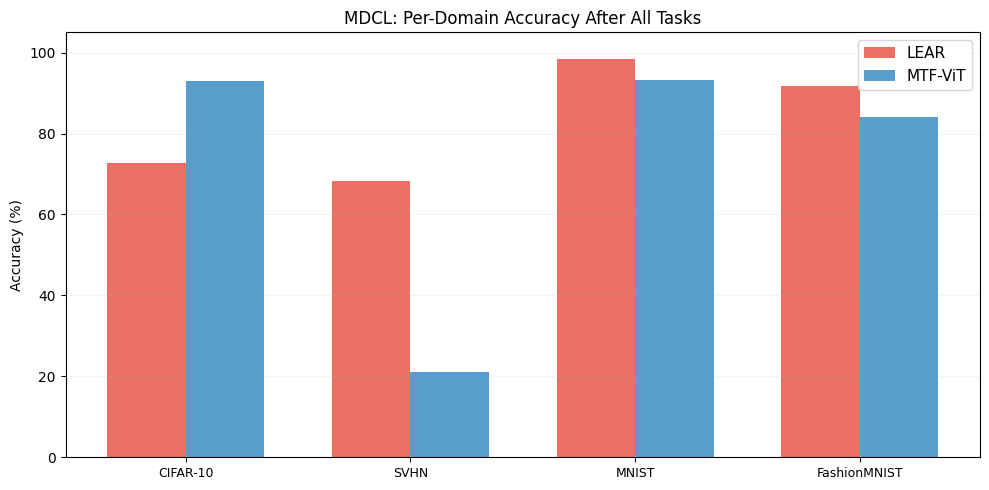


Key comparison:
  LEAR: 2 ViTs (partially unfrozen), task boundaries, Mahalanobis routing
  MTF:  1 ViT (fully frozen), NO task boundaries, centroid routing


In [7]:
# ============================================================
# Compare Results
# ============================================================
import matplotlib.pyplot as plt

print('='*60)
print('MULTI-DOMAIN CONTINUAL LEARNING RESULTS')
print(f'{N_DOMAINS} domains, {EPOCHS} epochs/domain')
print('='*60)
print(f'{"Domain":15s} {"LEAR":>8s} {"MTF-ViT":>8s} {"Gap":>8s}')
print('-'*45)
for d in domains:
    name = d['name']
    l = lear_results.get(name, 0)
    m = mtf_results.get(name, 0)
    print(f'{name:15s} {l:8.3f} {m:8.3f} {m-l:+8.3f}')
print('-'*45)
print(f'{"Average":15s} {lear_results["Avg"]:8.3f} {mtf_results["Avg"]:8.3f} '
      f'{mtf_results["Avg"]-lear_results["Avg"]:+8.3f}')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
names = [d['name'] for d in domains]
x = np.arange(len(names))
w = 0.35
ax.bar(x-w/2, [lear_results[n]*100 for n in names], w, color='#E74C3C', label='LEAR', alpha=0.8)
ax.bar(x+w/2, [mtf_results[n]*100 for n in names],  w, color='#2E86C1', label='MTF-ViT', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Accuracy (%)'); ax.set_title('MDCL: Per-Domain Accuracy After All Tasks')
ax.legend(fontsize=11); ax.grid(True, alpha=0.15, axis='y')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('mtf_vs_lear_mdcl.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey comparison:')
print('  LEAR: 2 ViTs (partially unfrozen), task boundaries, Mahalanobis routing')
print('  MTF:  1 ViT (fully frozen), NO task boundaries, centroid routing')
